In [113]:
import torch

In [114]:
x = torch.randn(3,requires_grad=True)
print(x)

tensor([1.6270, 0.1371, 0.8062], requires_grad=True)


Now we want to calculate the gradients of some function with respect to x so now whenever we do operations with this tensor pytorch will create a so called computational graph.
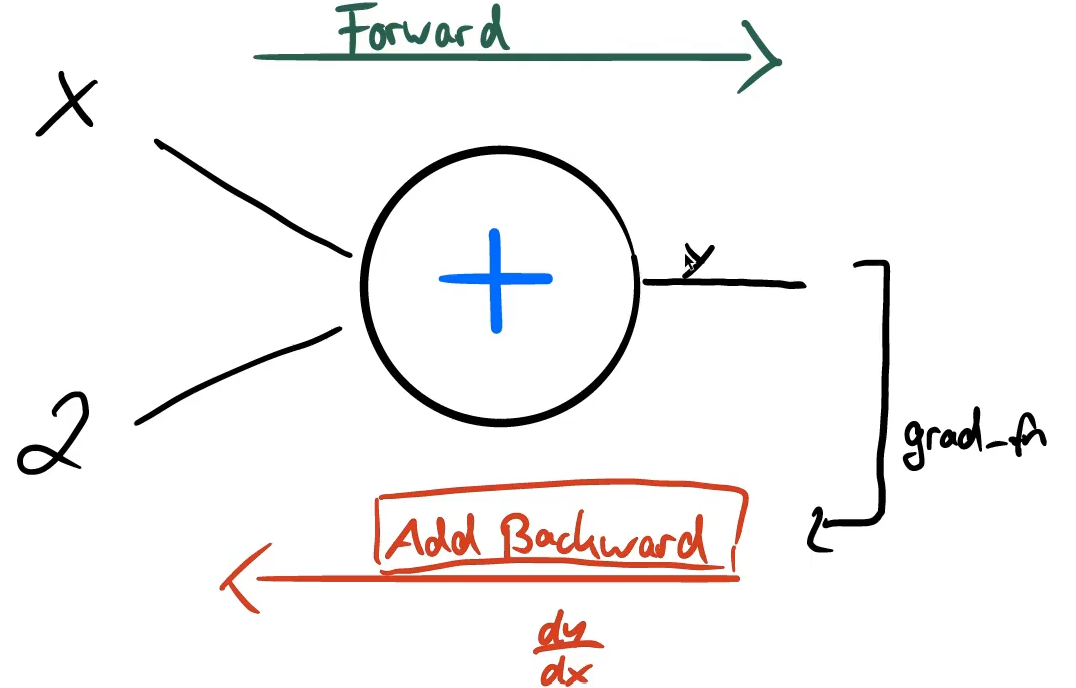

In [115]:
y = x+2
print(y)

tensor([3.6270, 2.1371, 2.8062], grad_fn=<AddBackward0>)


In [116]:
z = y*y*2
print(z)

tensor([26.3104,  9.1342, 15.7496], grad_fn=<MulBackward0>)


In [117]:
#z =z.mean()
#print(z)

In [118]:
v =torch.tensor([0.1,1.0,0.001], dtype=torch.float32)

In [119]:
z.backward(v) # dz/dx
print(x.grad)

tensor([1.4508, 8.5483, 0.0112])


In [120]:
# prevent from tracking
# 1. x.requires_grad(False)
# 2. x.detach()
# 3. with torch.no_grad()


In [122]:
x.requires_grad_(False)
print(x)

tensor([1.6270, 0.1371, 0.8062])


In [123]:
y =x.detach()
print(y)

tensor([1.6270, 0.1371, 0.8062])


In [124]:
with torch.no_grad():
  y = x+2
  print(y)

tensor([3.6270, 2.1371, 2.8062])


Whenever we call the backward function then the gradient for this tensor will be acumulated into the dot grad attribute, so the values will be summed up, so here we must be very carefull

Ας το αναλύσουμε **βήμα προς βήμα, γραμμή προς γραμμή**, βλέποντας ακριβώς τι σκέφτεται ο υπολογιστής σε κάθε κώδικα, ώστε να μην σου μείνει καμία απορία.

---

### Γραμμή 1: `weights = torch.ones(4, requires_grad=True)`

* **`torch.ones(4)`**: Δημιουργεί έναν πίνακα με 4 θέσεις, όπου η καθεμία έχει την τιμή `1.0`.

$$\text{weights} = [1.0, 1.0, 1.0, 1.0]$$


* **`requires_grad=True`**: Αυτή είναι η πιο σημαντική λέξη-κλειδί στο PyTorch. Λέει στο πρόγραμμα: *"Άνοιξε τα μάτια σου και κατέγραφε κάθε πράξη που κάνουμε με αυτά τα νούμερα"*.
* Χωρίς αυτό, τα νούμερα είναι απλά σταθερές.
* Με αυτό, το PyTorch χτίζει ένα **κρυφό δέντρο (γράφημα)** με τις πράξεις, ώστε να μπορεί να βρει την "κατεύθυνση" που πρέπει να αλλάξουν τα βάρη για να βελτιωθεί το μοντέλο.



---

### Γραμμή 2: `for epoch in range(3):`

Ο κώδικας θα επαναληφθεί 3 φορές (για `epoch = 0`, `epoch = 1`, `epoch = 2`).

---

### Γραμμή 3: `model_output = (weights * 3).sum()`

Εδώ γίνεται ο υπολογισμός. Ας τον σπάσουμε στα δύο:

1. `weights * 3`: Πολλαπλασιάζει κάθε στοιχείο του πίνακα επί 3.
* Επειδή τα weights είναι $[1, 1, 1, 1]$, τώρα γίνονται $[3, 3, 3, 3]$.


2. `.sum()`: Προσθέτει όλα τα στοιχεία μεταξύ τους ($3 + 3 + 3 + 3 = 12$).
* Άρα, `model_output = 12`.



---

### Γραμμή 4: `model_output.backward()`

Εδώ συμβαίνει η μαγεία του **autograd (αυτόματης παραγώγισης)**.
Το PyTorch κοιτάζει προς τα πίσω (από το `model_output` προς τα `weights`) και κάνει την εξής μαθηματική ερώτηση:

> *«Αν αλλάξω λίγο την τιμή κάθε βάρους ($w$), πόσο θα αλλάξει το συνολικό αποτέλεσμα ($12$);»*

* Η εξίσωση που συνδέει την έξοδο με τα βάρη είναι: $\text{Output} = 3w_1 + 3w_2 + 3w_3 + 3w_4$.
* Η παράγωγος (ο ρυθμός μεταβολής) κάθε $w$ είναι το **$3$**.
* Το PyTorch αποθηκεύει αυτό το αποτέλεσμα (`3`) μέσα στο ίδιο το tensor των βαρών, στη μεταβλητή `weights.grad`.

---

### Γραμμή 5: `print(weights.grad)`

Εδώ τυπώνεται τι έχει αποθηκευτεί στο `weights.grad`. Και εδώ γίνεται το μεγάλο "μπέρδεμα" που βλέπεις στην οθόνη.

Ας δούμε τι γίνεται **σε κάθε επανάληψη (epoch) ξεχωριστά**:

#### 1η Επανάληψη (`epoch = 0`):

* Το `weights.grad` ξεκινάει κενό (`None`).
* Γίνεται το `.backward()` και βρίσκει κλίση **`3`** για κάθε θέση.
* Το PyTorch **γράφει** το `3` στο `weights.grad`.
* **Τυπώνει:** `[3., 3., 3., 3.]`

#### 2η Επανάληψη (`epoch = 1`):

* Ξανατρέχει ο βρόχος. Το `model_output.backward()` υπολογίζει ξανά την κλίση, η οποία είναι πάλι **`3`**.
* **Προσοχή:** Το PyTorch **δεν σβήνει** το προηγούμενο 3. Αντίθετα, **το προσθέτει (accumulate)** στο παλιό!
* Παλιό `3` + Νέο `3` = **`6`**.


* **Τυπώνει:** `[6., 6., 6., 6.]`

#### 3η Επανάληψη (`epoch = 2`):

* Υπολογίζεται ξανά κλίση **`3`**.
* Προστίθεται στο προηγούμενο 6:
* Παλιό `6` + Νέο `3` = **`9`**.


* **Τυπώνει:** `[9., 9., 9., 9.]`

---

### Περίληψη

Ο κώδικας αυτός σου δείχνει δύο βασικούς κανόνες του PyTorch:

1. Το `requires_grad=True` ενεργοποιεί την καταγραφή των παραγώγων.
2. Το PyTorch **συσσωρεύει (μαζεύει) τα gradients** από προηγούμενους γύρους αντί να τα αντικαθιστά αυτόματα. Γι' αυτό, στην κανονική εκπαίδευση νευρωνικών δικτύων, είμαστε υποχρεωμένοι να τα μηδενίζουμει σε κάθε γύρο (με `optimizer.zero_grad()` ή `weights.grad.zero_()`), αλλιώς τα νούμερα "φεύγουν στον Θεό" (όπως αυξήθηκαν από το 3 στο 6 και στο 9).

In [128]:
weights = torch.ones(4, requires_grad=True)
for epoch in range(3):
  model_output = (weights*3).sum()
  model_output.backward()
  print(weights.grad)
  # with grad.zero we solve the problem
  # weights.grad.zero_()

tensor([3., 3., 3., 3.])
tensor([6., 6., 6., 6.])
tensor([9., 9., 9., 9.])
